### Purpose
This notebook serves as the exploratory data analysis foundation for an end-to-end machine learning pipeline using CRMLS residential sales data to predict the final close price of a single-family property in California based on its characteristics at the time of the query.

### Background
As previously mentioned, the data is from California Regional Multiple Listing Service (CRMLS), a private cooperative database operated by regional association of real estate brokers.

Since we're working with real estate, it is important to contexualize the meaning of the data with a few key terms.
1. Listing: Seller signs a listing agreement with licensed agent, and agent enters ListPrice, LivingArea, BedroomsTotal, and Address fields into the MLS.
    
    1a. ListPrice: what the seller wants

    1b. ClosePrice: what the market will pay

2. Buyer Preapproval & Offers: Buyers typically obtain a mortgage preapproval letter before submitting an offer, which is based on income, credit score, and debt-to-income ratio and used as a financial qualification filter.

    2a. Compare ListPrice vs ClosePrice plus days-on-market. Downward large difference between list and close price may signal overpriced listing or deteriorating market.
3. Purchase Agreement & Escrow: Offer accepted, both parties sign purchase agreement that locks in the price, contingencies, and a closing date is agreed between both buyer and seller. Changes to "Pending" in MLS.

    3a. Contingencies: conditions that are met for the deal to proceed, which commonly include inspection, appraisal, and financing.
    
    3b. Then the escrow, neutral third-party account that holds buyer's deposit and all transaction funds, will do home inspection, appraisal, loan underwriting, title search, and final paperwork.

    3c. Data may have a property with multiple listing records or status changes. It's reflecting a real transaction that failed to close.

Data was downloaded on 9/26/2026 and the monthly data was from January 2024 to April 2026, or roughly 27 months of CRMLS data. It will be partition in this way.
| Period | Role | Use |
|---|---|---|
| Jan 2024 → Feb 2026 | **Training** | EDA, cleaning decisions, feature engineering, fit models |
| Mar 2026 | **Validation** | Hyperparameter tuning / model selection |
| Apr 2026 | **Test** | Final evaluation only |

‼️ update this: In this notebook, we will look at schema drift, ClosePrice (target value), numeric variables,  #TODO: Summarize what you did.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# first available 
df_2024_01 = pd.read_csv('dataset/CRMLSSold202401_filled.csv')
df_2024_01.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,False,False
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,False,False
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,False,NaN,NaN,92308,NaN,217800.0,NaN,False,False
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,False,NaN,NaN,93544,0.0,108883.0,NaN,False,False


In [3]:
df_2026_02 = pd.read_csv('dataset/CRMLSSold202602.csv')
df_2026_02.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName
0,BayEast,Oakland,Carpet,NaN,NaN,NaN,False,1210000.0,1155025463,mike.swiderski@cbnorcal.com,...,NaN,False,2.0,NaN,94598,NaN,27600.0,NaN,CRMLS,CRMLS_BMLS
1,Newport,Newport,"Tile,Wood",True,NaN,NaN,False,3150000.0,1154998305,casey@caseyoconnorgroup.com,...,1.0,True,1.0,Newport Mesa Unified,92625,0.0,3540.0,NaN,CRMLS,CRMLS_CRM
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1154943263,ben@strockrealestate.com,...,NaN,False,2.0,Other,95032,NaN,10454.0,NaN,CRMLS,CRMLS_MLSL
3,NorthSanDiegoCounty,NorthSanDiegoCounty,Laminate,False,NaN,NaN,False,649999.0,1154868125,listings@bottrellteam.com,...,NaN,NaN,1.0,San Diego Unified,92105,0.0,5500.0,NaN,CRMLS,CRMLS_CRP
4,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,NaN,NaN,NaN,700000.0,1154785403,meriahdruliner@gmail.com,...,NaN,NaN,NaN,NaN,92070,0.0,3484800.0,NaN,CRMLS,CRMLS_CRP


##### Columns have changed over the years.

In [39]:
# Similarities: items in both sets
similar = df_2024_01.columns.intersection(df_2026_02.columns)
print("similar:", similar)

# Differences
only_in_2024 = df_2024_01.columns.difference(df_2026_02.columns)
only_in_2026 = df_2026_02.columns.difference(df_2024_01.columns)
print("only in Jan 2024:", only_in_2024)
print("only in Feb 2026:", only_in_2026)

similar: Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'TaxYear', 'BuildingAreaT

#### Map Schema Drift

In [5]:
# Column count over time
# Which columns existed in which months
# What changed from month to month
# Drift by year
# datatype changes

In [ ]:
import glob, os, re
files = sorted(glob.glob('dataset/CRMLSSold*.csv'))

records = []
schema_by_year_month = {}   
for f in files:
    year_month = re.search(r'(\d{6})', os.path.basename(f)).group(1)  # extract year_month from file name e.g. '202401'
    cols = pd.read_csv(f, nrows=0).columns                        
    schema_by_year_month[year_month] = set(cols)
    records.append({
        'year_month': pd.to_datetime(year_month, format='%Y%m'),
        'n_columns': len(cols),
        'filled': '_filled' in f,
    })

In [7]:
col_counts = pd.DataFrame(records).sort_values('year_month').reset_index(drop=True)
col_counts

,year_month,n_columns,filled
0,2024-01-01,80,True
1,2024-02-01,78,False
2,2024-03-01,80,True
3,2024-04-01,80,True
4,2024-05-01,80,True
5,2024-06-01,80,True
6,2024-07-01,80,True
7,2024-08-01,78,False
8,2024-09-01,78,False
9,2024-10-01,78,False


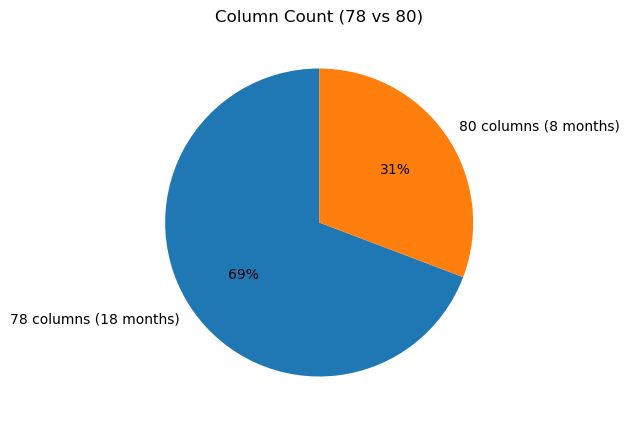

In [8]:
import matplotlib.pyplot as plt

counts = col_counts['n_columns'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts.values,
    labels=[f'{n} columns ({c} months)' for n, c in counts.items()
],
    autopct='%1.0f%%',
    startangle=90,
)
ax.set_title('Column Count (78 vs 80)')
plt.show()

In [ ]:
all_cols = sorted(set().union(*schema_by_year_month.values()))
months_sorted = sorted(schema_by_year_month.keys())
columns_existence_per_month = pd.DataFrame(
    { ym: [1 if c in schema_by_year_month[ym] else 0 for c in all_cols] for ym in months_sorted},
    index=all_cols,
)
columns_existence_per_month

,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,...,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
AboveGradeFinishedArea,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFee,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AssociationFeeFrequency,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
AttachedGarageYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
BasementYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
WaterfrontYN,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
YearBuilt,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
latfilled,1,0,1,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
col_month_counts = pd.Series(
    {c: sum(c in cols for cols in schema_by_year_month.values()) for c in all_cols},
    name='n_months_present'
).sort_values(ascending=False)

col_month_counts

AboveGradeFinishedArea         26
ListAgentEmail                 26
MiddleOrJuniorSchool           26
MainLevelBedrooms              26
MLSAreaMajor                   26
                               ..
lonfilled                       7
BuyerAgencyCompensation         4
BuyerAgencyCompensationType     4
OriginatingSystemSubName        1
OriginatingSystemName           1
Name: n_months_present, Length: 84, dtype: int64

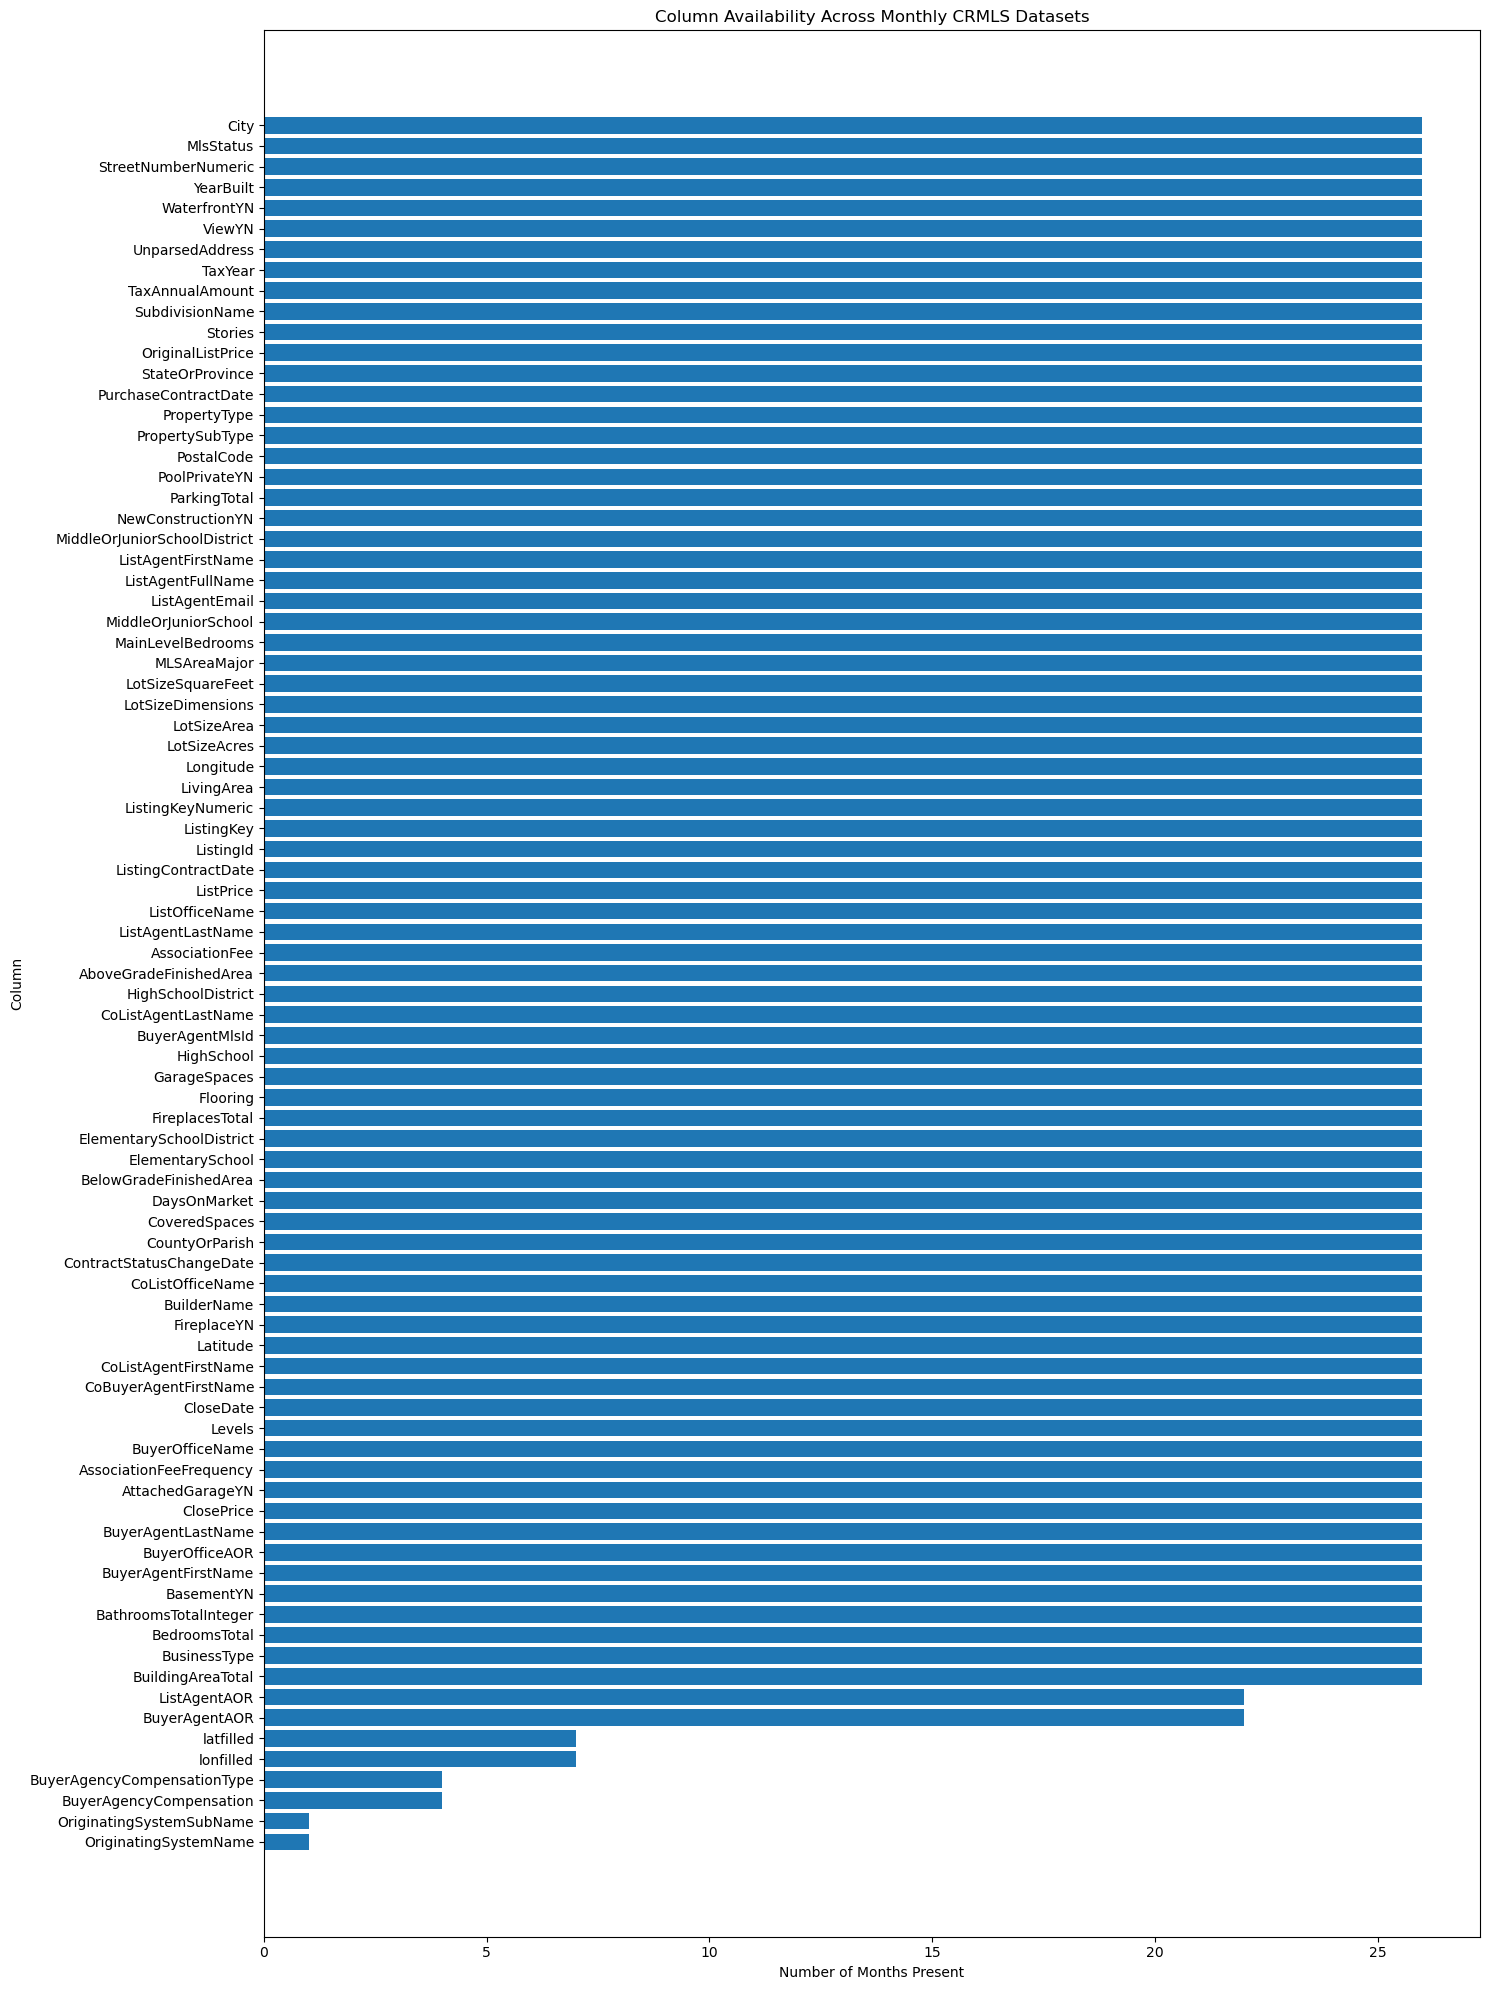

In [18]:
columns_vs_month_count = col_month_counts.sort_values(ascending=True)

plt.figure(figsize=(15, 20))

plt.barh(
    columns_vs_month_count.index,
    columns_vs_month_count.values
)

plt.xlabel("Number of Months Present")
plt.ylabel("Column")
plt.title("Column Availability Across Monthly CRMLS Datasets")

plt.tight_layout()
plt.show()

In [ ]:
total_months = len(schema_by_year_month)
print("total months:", total_months)

cols_in_all_months = col_month_counts[col_month_counts == total_months].index
cols_in_all_months

total months: 26


Index(['AboveGradeFinishedArea', 'ListAgentEmail', 'MiddleOrJuniorSchool',
       'MainLevelBedrooms', 'MLSAreaMajor', 'LotSizeSquareFeet',
       'LotSizeDimensions', 'LotSizeArea', 'LotSizeAcres', 'Longitude',
       'LivingArea', 'ListingKeyNumeric', 'ListingKey', 'ListingId',
       'ListingContractDate', 'ListPrice', 'ListOfficeName',
       'ListAgentLastName', 'ListAgentFullName',
       'MiddleOrJuniorSchoolDistrict', 'MlsStatus', 'NewConstructionYN',
       'StreetNumberNumeric', 'YearBuilt', 'WaterfrontYN', 'ViewYN',
       'UnparsedAddress', 'TaxYear', 'TaxAnnualAmount', 'SubdivisionName',
       'Stories', 'OriginalListPrice', 'StateOrProvince',
       'PurchaseContractDate', 'PropertyType', 'PropertySubType', 'PostalCode',
       'PoolPrivateYN', 'ParkingTotal', 'AssociationFee', 'ListAgentFirstName',
       'City', 'BuyerAgentMlsId', 'CloseDate', 'Levels', 'BuyerOfficeName',
       'AssociationFeeFrequency', 'AttachedGarageYN', 'BuyerOfficeAOR',
       'BuyerAgentLastName

#### No Data Type Drift for Each Column

In [19]:
dtype_by_month = {}
for f in files:
    ym = re.search(r'(\d{6})', os.path.basename(f)).group(1)
    df_tmp = pd.read_csv(f, low_memory=False)
    dtype_by_month[ym] = df_tmp.dtypes.astype(str)

dtype_matrix = pd.DataFrame(dtype_by_month).reindex(all_cols)
dtype_matrix.columns = pd.to_datetime(dtype_matrix.columns, format='%Y%m')
dtype_matrix = dtype_matrix.sort_index(axis=1)
dtype_matrix

,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01
AboveGradeFinishedArea,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFee,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
AssociationFeeFrequency,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
AttachedGarageYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
BasementYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ViewYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
WaterfrontYN,object,object,object,object,object,object,object,object,object,object,...,object,object,object,object,object,object,object,object,object,object
YearBuilt,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
latfilled,bool,NaN,bool,bool,bool,bool,bool,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
#Find which columns actually drifted:
n_distinct_dtypes = dtype_matrix.apply(lambda row: row.dropna().nunique(), axis=1)
drifted_cols = n_distinct_dtypes[n_distinct_dtypes > 1].sort_values(ascending=False)
drifted_cols   

Series([], dtype: int64)

#### General Data Quality

- count missing values
- inspect duplicate records
- find ClosePrice <= 0
- look for impossible dates
- check zero/negative LivingArea
- inspect outliers
- compare schema across months
- missingness percentage by feature
- investigate whether missingness is systematic

#### Understand What We Want to Predict: ClosePrice

In [11]:
# TODO: 
#  df["ClosePrice"].describe()
# sns.histplot(df["ClosePrice"], bins=50)
# sns.histplot(np.log1p(df["ClosePrice"]), bins=50) (using bins)

Also use a boxplot.
You're likely investigating:
- right skew
- luxury-home tail
- extreme transactions
- whether variance increases with price
This matters because the handbook specifically describes real-estate prices and errors as multi-scale and right-skewed, which is one reason it emphasizes percentage-based metrics such as MdAPE

#### Numeric variables

Then analyze things like:
- LivingArea
- LotSizeSquareFeet
- BedroomsTotal
- BathroomsTotalInteger
- YearBuilt
- TaxAnnualAmount
- Stories
- FireplacesTotal

distribution
missing %
zero / impossible values
outliers
unique values

#### Geography
Location is one of the major predictive feature families.

Median ClosePrice by:
- City
- ZIP
- MLS area
- school district

| ZIP | Sales | Median ClosePrice | Median $/sqft |
|---|---:|---:|---:|
| ... | ... | ... | ... |
| ... | ... | ... | ... |

### Geographical Interactions
- LivingArea vs geography
- Plot median price vs. living area separately for several cities.

#### Categorical 

categorical_summary = pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(),
    "missing_pct": df[categorical_cols].isna().mean() * 100
}).sort_values("n_unique", ascending=False)